In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from fractions import Fraction

# Zadanie 1

Dla funkcji $\tan(x)$ w $x = 1$ oblicz przybliżoną wartość pochodnej, używająć wzoru
$$ f'(x) \approx \frac{f(x+h) - f(x)}{h} $$

In [2]:
def d_f_1(x, h):
    return (np.tan(x + h) - np.tan(x)) / h

oraz
$$ f'(x) \approx \frac{f(x+h) - f(x-h)}{2h} $$

In [3]:
def d_f_2(x, h):
    return (np.tan(x + h) - np.tan(x - h)) / (2 * h)

Wartość wynikająca z tożsamości
$$ \tan'(x) = 1 + \tan^2(x) $$

In [4]:
def d_f(x):
    return 1 + np.tan(x) ** 2

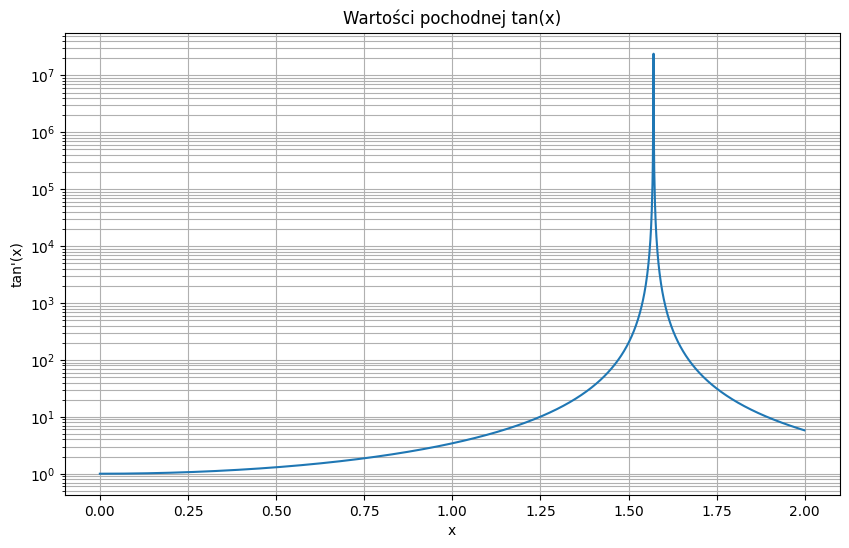

In [5]:
t = np.arange(0, 2, 0.001)
plt.figure(figsize=(10,6))
plt.semilogy(t, d_f(t))
plt.xlabel("x")
plt.ylabel("tan'(x)")
plt.title("Wartości pochodnej tan(x)")
plt.grid(True, which="both", ls="-")
plt.show()

$\tan''(x)$ i $\tan'''(x)$

In [6]:
def d_2_f(x):
    return 2 * np.tan(x) / (np.cos(x) ** 2)


def d_3_f(x):
    return (4 * np.sin(x) ** 2 + 2) / (np.cos(x) ** 4)

$$ |f(t)| \le M \ \text{dla} \ t \in [x-h, x+h] $$

In [7]:
def M(bounds):
    result = minimize_scalar(lambda x: -np.tan(x), bounds=bounds, method="bounded")
    return -result.fun

### Wartości błędów metody, numerycznego, obliczeniowego

In [8]:
hs = [10**-k for k in range(17)]  # 10**-k, k = 0,...,16
x = 1

#### Różnica w przód

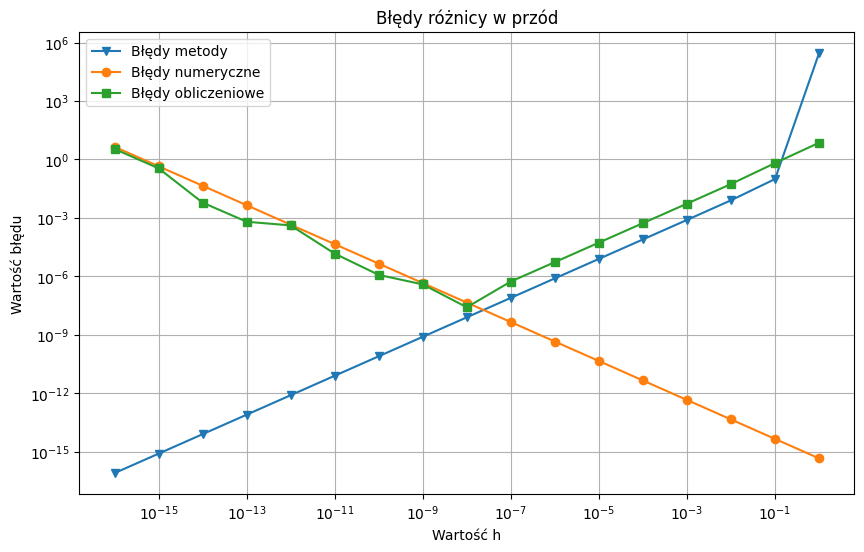

In [9]:
truncation_errors = []  # "Błędy metody"
rounding_errors = []  # "Błędy numeryczne"
computational_errors = []  # "Błędy obliczeniowe"

for h in hs:
    truncation_errors.append(M((x - h, x + h)) * h / 2)
    rounding_errors.append(2 * np.finfo(float).eps / h)
    computational_errors.append(abs(d_f(x) - d_f_1(x, h)))
    
plt.figure(figsize=(10,6))
plt.loglog(hs, truncation_errors, label="Błędy metody", marker="v")
plt.loglog(hs, rounding_errors, label="Błędy numeryczne", marker="o")
plt.loglog(hs, computational_errors, label="Błędy obliczeniowe", marker="s")
plt.xlabel("Wartość h")
plt.ylabel("Wartość błędu")
plt.title("Błędy różnicy w przód")
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

$$ h_\text{min} \approx 2 \sqrt{\epsilon_\text{mach}/M} \ \text{gdzie} \ M \approx |f''(x)| $$

h_min_computed=1e-08 h_min_formula=9.123695225180455e-09


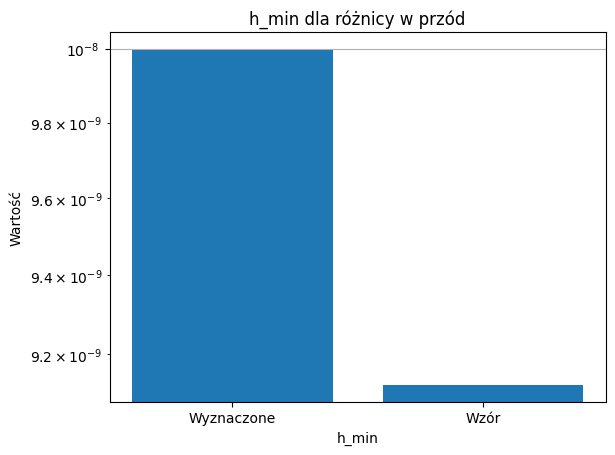

In [10]:
h_min_computed = hs[np.argmin(computational_errors)]
h_min = 2 * np.sqrt(np.finfo(float).eps / abs(d_2_f(x)))

print(f"h_min_computed={h_min_computed} h_min_formula={h_min}")

plt.bar(["Wyznaczone", "Wzór"], [h_min_computed, h_min])
plt.yscale("log")
plt.xlabel("h_min")
plt.ylabel("Wartość")
plt.title("h_min dla różnicy w przód")
plt.grid(True, axis="y", ls="-")
plt.show()

#### Różnica centralna

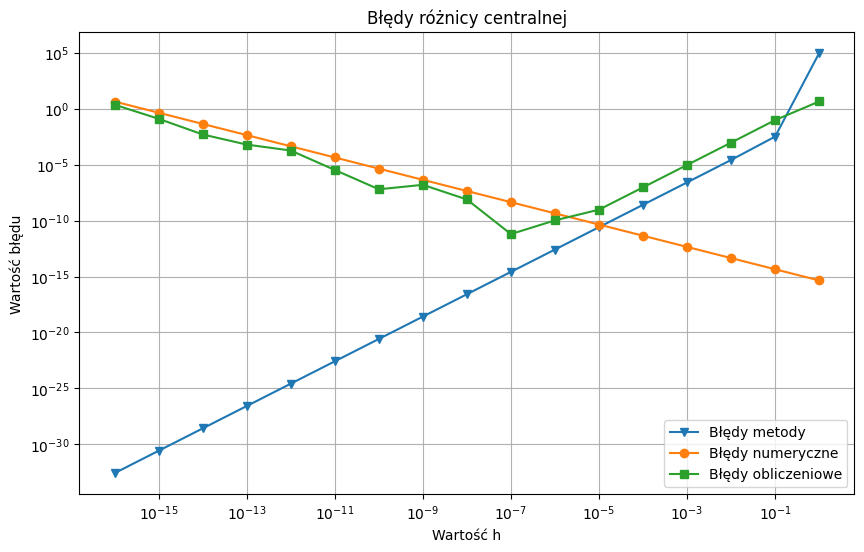

In [11]:
truncation_errors = []  # "Błędy metody"
rounding_errors = []  # "Błędy numeryczne"
computational_errors = []  # "Błędy obliczeniowe"

for h in hs:
    truncation_errors.append(M((x - h, x + h)) * h**2 / 6)
    rounding_errors.append(2 * np.finfo(float).eps / h)
    computational_errors.append(abs(d_f(x) - d_f_2(x, h)))

plt.figure(figsize=(10,6))
plt.loglog(hs, truncation_errors, label="Błędy metody", marker="v")
plt.loglog(hs, rounding_errors, label="Błędy numeryczne", marker="o")
plt.loglog(hs, computational_errors, label="Błędy obliczeniowe", marker="s")
plt.xlabel("Wartość h")
plt.ylabel("Wartość błędu")
plt.title("Błędy różnicy centralnej")
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

$$ h_\text{min} \approx \sqrt[3]{3 \epsilon_\text{mach}/M} \ \text{gdzie} \ M \approx |f'''(x)| $$

h_min_computed=1e-07 h_min_formula=2.2732741568390617e-06


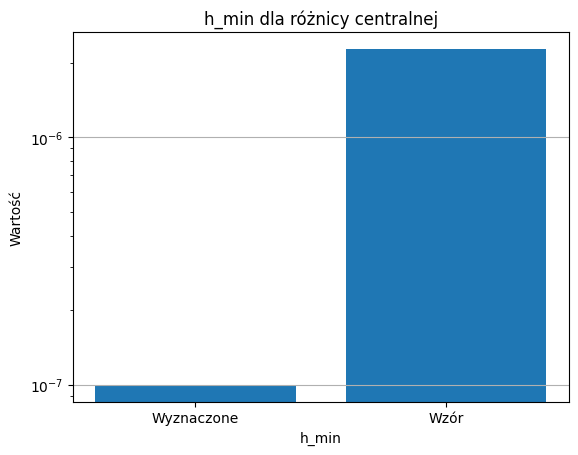

In [12]:
h_min_computed = hs[np.argmin(computational_errors)]
h_min = np.cbrt(3 * np.finfo(float).eps / abs(d_3_f(x)))

print(f"h_min_computed={h_min_computed} h_min_formula={h_min}")

plt.bar(["Wyznaczone", "Wzór"], [h_min_computed, h_min])
plt.yscale("log")
plt.xlabel("h_min")
plt.ylabel("Wartość")
plt.title("h_min dla różnicy centralnej")
plt.grid(True, axis="y", ls="-")
plt.show()

# Zadanie 2
Wygeneruj pierwsze n wyrazów ciągu zdefiniowanego równaniem różnicowym:
$$ x_{k+1} = 2.25x_k - 0.5x_{k-1} $$
z wyrazami początkowymi:
$$ x_0 = \frac{1}{3} \ \ \ \ \ x_1 = \frac{1}{12} $$

### Dokładne $x_k$

In [13]:
def x_k(k):
    return 4**-k / 3

### Pojedyńcza precyzja oraz n = 225

In [14]:
def seq_single_precision(n=225):
    xs = np.empty(n, dtype=np.float32)
    xs[0] = np.float32(1 / 3)
    xs[1] = np.float32(1 / 12)
    for i in range(2, n):
        xs[i] = 2.25 * xs[i - 1] - 0.5 * xs[i - 2]
    return xs

### Podwójna precyzja oraz n = 60

In [15]:
def seq_double_precision(n=60):
    xs = np.empty(n, dtype=np.float64)
    xs[0] = np.float64(1 / 3)
    xs[1] = np.float64(1 / 12)
    for i in range(2, n):
        xs[i] = 2.25 * xs[i - 1] - 0.5 * xs[i - 2]
    return xs

### Biblioteka fractions oraz n = 225

In [16]:
def seq_fraction(n=225):
    xs = np.empty(n, dtype=Fraction)
    xs[0] = Fraction(1, 3)
    xs[1] = Fraction(1, 12)
    for i in range(2, n):
        xs[i] = Fraction(2.25) * xs[i - 1] - Fraction(0.5) * xs[i - 2]
    return xs

In [17]:
single_precisions = seq_single_precision()
double_precisions = seq_double_precision()
fractions = seq_fraction()

single_precision_n = len(single_precisions)
double_precision_n = len(double_precisions)
fraction_n = len(fractions)
max_n = max(single_precision_n, double_precision_n, fraction_n)

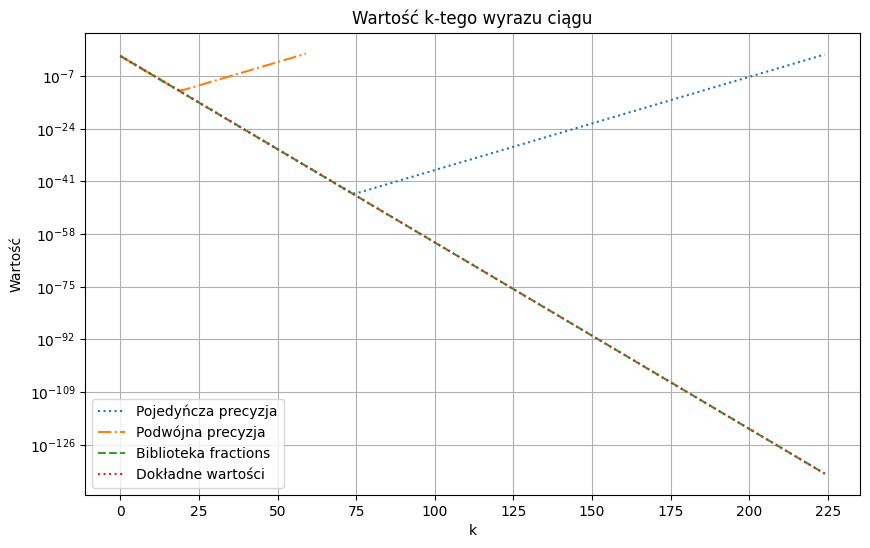

In [18]:
# %smatplotlib widget
plt.figure(figsize=(10,6))
plt.semilogy(
    np.arange(single_precision_n),
    single_precisions,
    label="Pojedyńcza precyzja",
    linestyle="dotted",
)
plt.semilogy(
    np.arange(double_precision_n),
    double_precisions,
    label="Podwójna precyzja",
    linestyle="dashdot",
)
plt.semilogy(
    np.arange(fraction_n),
    [float(x) for x in fractions],
    label="Biblioteka fractions",
    linestyle="dashed",
)
plt.semilogy(
    np.arange(max_n),
    [float(x_k(k)) for k in range(max_n)],
    label="Dokładne wartości",
    linestyle="dotted",
)
plt.xticks(np.arange(0, 226, step=25))
plt.xlabel("k")
plt.ylabel("Wartość")
plt.title("Wartość k-tego wyrazu ciągu")
plt.legend()
plt.grid(True)
plt.show()

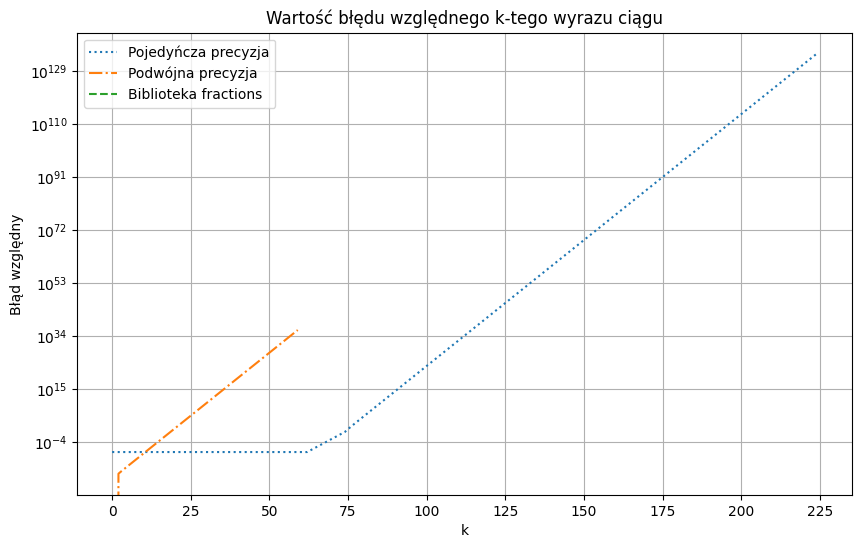

In [19]:
single_precision_errors = []
double_precision_errors = []
fraction_errors = []

for i in range(max_n):
    exact_x = x_k(i)
    if i < single_precision_n:
        single_precision_errors.append(abs(single_precisions[i] - exact_x) / exact_x)
    if i < double_precision_n:
        double_precision_errors.append(abs(double_precisions[i] - exact_x) / exact_x)
    if i < fraction_n:
        fraction_errors.append(abs(fractions[i] - exact_x) / exact_x)

plt.figure(figsize=(10,6))
plt.semilogy(
    np.arange(single_precision_n),
    single_precision_errors,
    label="Pojedyńcza precyzja",
    linestyle="dotted",
)
plt.semilogy(
    np.arange(double_precision_n),
    double_precision_errors,
    label="Podwójna precyzja",
    linestyle="dashdot",
)
plt.semilogy(
    np.arange(fraction_n),
    fraction_errors,
    label="Biblioteka fractions",
    linestyle="dashed",
)
plt.xticks(np.arange(0, 226, step=25))
plt.xlabel("k")
plt.ylabel("Błąd względny")
plt.title("Wartość błędu względnego k-tego wyrazu ciągu")
plt.legend()
plt.grid(True)
plt.show()